In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/EDA_ML/financial_data.csv")

In [3]:
trend_df = df[['symbol', 'year_id', 'sales', 'company_name']].copy()

# sort properly
trend_df = trend_df.sort_values(['symbol', 'year_id'])

In [4]:
def compute_trend(group):
    group = group.sort_values('year_id').tail(5)
    
    if len(group) < 3:
        return "INSUFFICIENT_DATA"
    
    x = np.arange(len(group))
    y = group['sales'].values
    
    slope, _ = np.polyfit(x, y, 1)
    
    # classify trend
    if slope > 0.05 * y.mean():
        return "UP"
    elif slope < -0.05 * y.mean():
        return "DOWN"
    else:
        return "FLAT"

In [5]:
trend_labels = trend_df.groupby('symbol').apply(compute_trend)

trend_labels = trend_labels.reset_index()
trend_labels.columns = ['symbol', 'trend']

In [6]:
trend_df = trend_df.merge(trend_labels, on='symbol', how='left')

In [7]:
top20 = (
    trend_df.groupby('symbol')['sales']
    .mean()
    .nlargest(20)
    .index
)

top_df = trend_df[trend_df['symbol'].isin(top20)]

In [8]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

forecast_rows = []

for symbol in top20:
    temp = trend_df[trend_df['symbol'] == symbol].sort_values('year_id')
    
    if len(temp) < 5:
        continue
    
    y = temp['sales'].values
    
    try:
        model = ExponentialSmoothing(y, trend='add', seasonal=None)
        fit = model.fit()
        
        forecast = fit.forecast(1)[0]
        
        forecast_rows.append({
            'symbol': symbol,
            'forecast_sales_next_year': forecast
        })
        
    except:
        continue

forecast_df = pd.DataFrame(forecast_rows)

In [9]:
forecast_df['lower_bound'] = forecast_df['forecast_sales_next_year'] * 0.9
forecast_df['upper_bound'] = forecast_df['forecast_sales_next_year'] * 1.1

In [10]:
forecast_df['is_estimate'] = True
forecast_df['note'] = "Model-based estimate. Not financial advice."

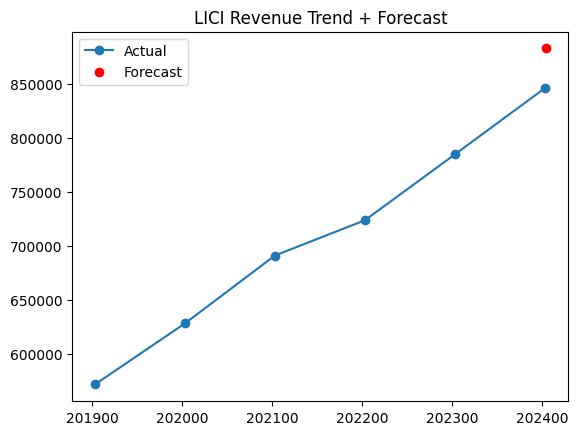

In [11]:
import matplotlib.pyplot as plt

symbol = list(top20)[0]

temp = trend_df[trend_df['symbol'] == symbol]

plt.plot(temp['year_id'], temp['sales'], marker='o', label='Actual')

forecast_val = forecast_df[forecast_df['symbol'] == symbol]['forecast_sales_next_year'].values

if len(forecast_val) > 0:
    plt.scatter(temp['year_id'].max() + 1, forecast_val[0], color='red', label='Forecast')

plt.title(f"{symbol} Revenue Trend + Forecast")
plt.legend()
plt.show()